In [2]:
import os

import torch
import numpy as np

from flonacomldft.gaussian_utils import MoG
import matplotlib.pyplot as plt

from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

from flonacomldft.full_adaptive_sampling import adaptive_sampling

from flonacomldft.utils.diagnostics import avg_windows
from flonacomldft.utils.plots import set_plot_sequential_data

from ase.units import kB

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import json

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = 'cpu'

sep = 1.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-1 * torch.eye(2)]

target = MoG(means, covars, weights=[0.2, 0.8])

In [4]:
n_samples = 5000

target_samples = target.sample(n_samples)
target_us = target.U(target_samples)
id_mode = torch.zeros(n_samples)

dataset = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T

train = dataset[:int(n_samples*0.8)]
test = dataset[int(n_samples*0.8):]

In [5]:
T = 300
target_energy = lambda x: target.U(x) / (1/(kB*T))
mlp_dic = {'model': target_energy}

In [6]:
n_blocks = 4
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=50,
    lr=1e-3,
    use_scheduler=False,
    step_schedule=100,
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
    compute_part_ratio=True,
    energy_type='mlp',
    mlp_model=target.U,
    n_prop=100,
    batch_size=8000,
)

COMPUTE PARTICIPATION RATIO:  True
train shape:  torch.Size([4000, 2])
time:0.12 	 epoch=0.0e+00 	 loss: 2.54	Gd: 5e-01	lr: 1.00e-03	part ratio: 1.51e-02
time:0.56 	 epoch=5.0e+00 	 loss: 2.53	Gd: 5e-01	lr: 1.00e-03	part ratio: 1.15e-02
time:0.95 	 epoch=1.0e+01 	 loss: 2.52	Gd: 5e-01	lr: 1.00e-03	part ratio: 2.01e-02
time:1.33 	 epoch=1.5e+01 	 loss: 2.51	Gd: 5e-01	lr: 1.00e-03	part ratio: 1.06e-02
time:1.87 	 epoch=2.0e+01 	 loss: 2.48	Gd: 5e-01	lr: 1.00e-03	part ratio: 2.20e-02
time:2.27 	 epoch=2.5e+01 	 loss: 2.45	Gd: 5e-01	lr: 1.00e-03	part ratio: 1.09e-02
time:2.64 	 epoch=3.0e+01 	 loss: 2.40	Gd: 5e-01	lr: 1.00e-03	part ratio: 1.00e-02
time:3.03 	 epoch=3.5e+01 	 loss: 2.33	Gd: 5e-01	lr: 1.00e-03	part ratio: 2.48e-02
time:3.41 	 epoch=4.0e+01 	 loss: 2.24	Gd: 5e-01	lr: 1.00e-03	part ratio: 1.03e-02
time:3.80 	 epoch=4.5e+01 	 loss: 2.14	Gd: 4e-01	lr: 1.00e-03	part ratio: 2.24e-02


In [7]:
flow_hyperparams = {'n_iter': 100,
    'lr': 1e-3,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4,
    'compute_part_ratio': True,
    'n_prop': 100,
    'energy_type': 'mlp',
    'batch_size': 8000,
    }

# MCMC Params
n_runs = 8
n_chains = 30
n_steps = 50

# Init chains
init_samples = target.sample(n_chains)
init_us = target.U(init_samples)
init_id_mode = torch.zeros(n_chains)

init_mcmc = torch.cat([init_samples.T, init_us.reshape(1, -1), init_id_mode.reshape(1, -1)]).T


In [8]:
_ = adaptive_sampling([train], 
                         [test],
                         init_mcmc, 
                         dim=2,
                         dict_flows_init=[flow_dic],
                         dict_mlps_init=[mlp_dic],
                         mixture=False,
                         flow_hyperparams=[flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                         path=os.getcwd()
                        )

modes:  tensor([0.])
step: 0 	 acc: 1.00
step: 1 	 acc: 0.63
step: 2 	 acc: 0.60
step: 3 	 acc: 0.57
step: 4 	 acc: 0.50
step: 5 	 acc: 0.47
step: 6 	 acc: 0.57
step: 7 	 acc: 0.40
step: 8 	 acc: 0.47
step: 9 	 acc: 0.53
step: 10 	 acc: 0.43
step: 11 	 acc: 0.53
step: 12 	 acc: 0.53
step: 13 	 acc: 0.63
step: 14 	 acc: 0.60
step: 15 	 acc: 0.67
step: 16 	 acc: 0.60
step: 17 	 acc: 0.70
step: 18 	 acc: 0.57
step: 19 	 acc: 0.57
step: 20 	 acc: 0.70
step: 21 	 acc: 0.67
step: 22 	 acc: 0.60
step: 23 	 acc: 0.50
step: 24 	 acc: 0.47
step: 25 	 acc: 0.57
step: 26 	 acc: 0.43
step: 27 	 acc: 0.37
step: 28 	 acc: 0.60
step: 29 	 acc: 0.43
step: 30 	 acc: 0.50
step: 31 	 acc: 0.40
step: 32 	 acc: 0.40
step: 33 	 acc: 0.63
step: 34 	 acc: 0.50
step: 35 	 acc: 0.43
step: 36 	 acc: 0.53
step: 37 	 acc: 0.33
step: 38 	 acc: 0.60
step: 39 	 acc: 0.57
step: 40 	 acc: 0.63
step: 41 	 acc: 0.37
step: 42 	 acc: 0.53
step: 43 	 acc: 0.57
step: 44 	 acc: 0.37
step: 45 	 acc: 0.43
step: 46 	 acc: 0.43
st

In [9]:
from matplotlib.pyplot import cm
size=30
import matplotlib.pylab as pylab
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}
pylab.rcParams.update(params)

In [10]:
lims = {'x_min':-1.6, 'x_max': 2.2, 'y_min':-1.9, 'y_max': 1.9 }
device = 'cpu'

from matplotlib.ticker import FormatStrFormatter

## TODO: add to gaussian utils

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    img = plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 5, cmap='YlGn')
    #ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 6, colors='k', linestyles='--', linewidths=3)
        
    plt.colorbar(img, label='Probability', ticks=np.linspace(np.exp(Us_prop).min(), np.exp(Us_prop).max(), 5), format=FormatStrFormatter('%.1f'))
    plt.xticks(np.linspace(lims['x_min'], lims['x_max'], 3))
    plt.yticks(np.linspace(lims['y_min'], lims['y_max'], 3))

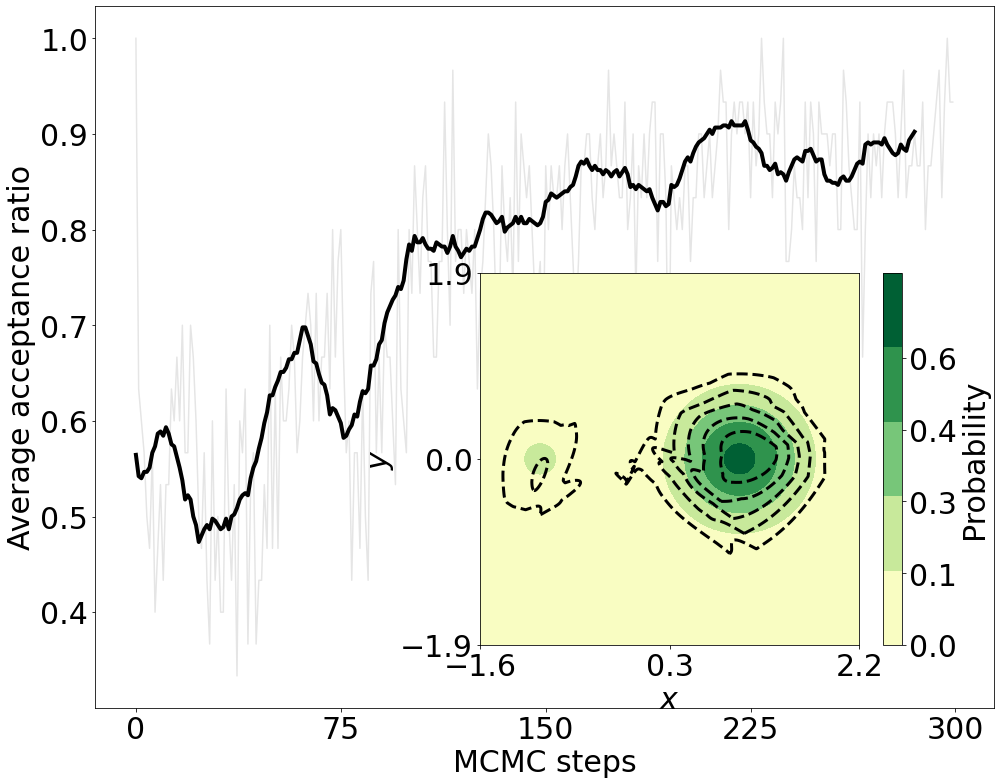

In [11]:
accs = torch.stack(_['accs'][:6])
accs_flatten = accs.reshape(-1, n_chains)

plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True
fig, ax1 = plt.subplots(figsize=(14, 11))
set_plot_sequential_data(accs_flatten.mean(dim=1), avg=False, color='k', alpha=0.1, window_size=10, axis=1, ax=ax1, init=0)

window_size = 15
axis = 1

x_avg = np.arange(len(avg_windows(accs_flatten.mean(dim=1), window_size, axis)))
y_avg = avg_windows(accs_flatten.mean(dim=1), window_size, axis)
ax1.plot(x_avg, y_avg, color="k", label='Average', linewidth=4)

ax1.set_xlabel('MCMC steps')
ax1.set_ylabel('Average acceptance ratio')

ax1.set_xticks(np.linspace(0, 300, 5))

l, b, h, w = .48, .18, .47, .47
ax2 = fig.add_axes([l, b, w, h])

model = _["dict_flows_training"][-1][0]['model']

flowlogprob = lambda x: -model.nll(x)
set_plot(ax2, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)

ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')

ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
